## Install TabPFN

In [1]:
!pip install -q -q --no-warn-conflicts tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.6/394.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00


## Ready Env

In [2]:
import os
from pathlib import Path

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
        Path(KAGGLE_RAW_CSV),
        Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
        Path("/kaggle/input/vlst-data/VLST.csv"),
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )

def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn
    
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    hf = secrets.get_secret("HF_TOKEN") or ""
    tabpfn = secrets.get_secret("NEW_TABPFN_TOKEN")
    return hf, tabpfn


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
RESULT_DIR.mkdir(parents=True, exist_ok=True)

try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

_hf_token, _tabpfn_token = _load_tabpfn_tokens()
if _tabpfn_token:
    os.environ["TABPFN_TOKEN"] = _tabpfn_token
if _hf_token:
    os.environ["HF_TOKEN"] = _hf_token

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)
print("are TOKENs ready:", bool(_tabpfn_token) and bool(_hf_token))

Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda
are TOKENs ready: True


## Fit and Eval

Running Stratified 5-Fold Cross Validation...
Processing Fold 1/5...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Found existing access token, reusing it for authentication.

00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


...

05:27 Fitting... Done!
00:20 Predicting... Done!
Processing Fold 4/5...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


04:27 Fitting... Done!
00:14 Predicting... Done!
Processing Fold 5/5...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


05:37 Fitting... Done!
00:17 Predicting... Done!


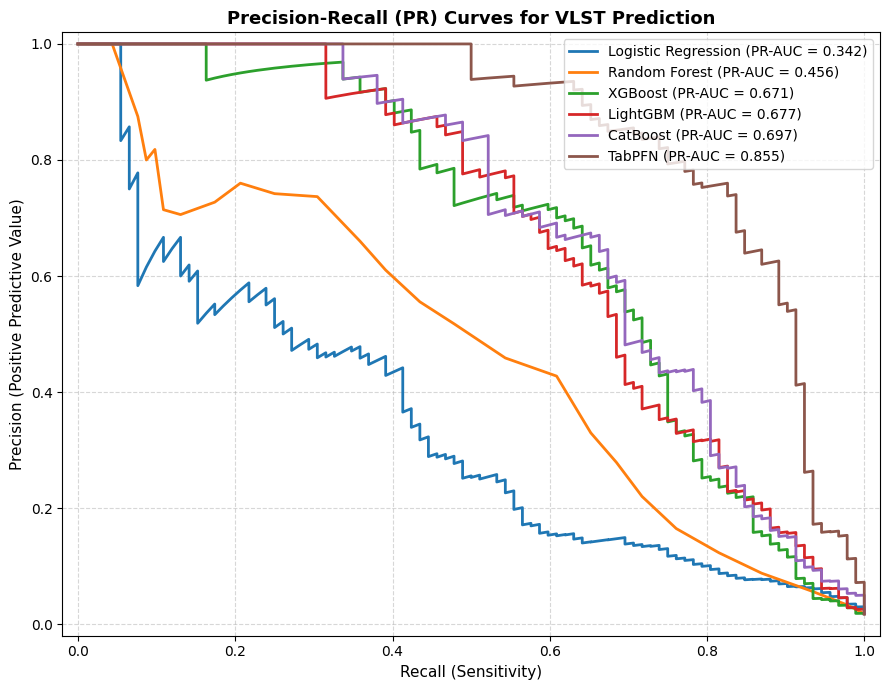


=== MODEL COMPARISON BENCHMARK ===
              Model Opt Threshold PR-AUC ROC-AUC F1-Score Accuracy Precision Recall
Logistic Regression         0.973 0.3418  0.9246   0.4270   0.9803    0.4419 0.4130
      Random Forest         0.090 0.4563  0.9313   0.5022   0.9786    0.4275 0.6087
            XGBoost         0.270 0.6709  0.9480   0.6629   0.9884    0.6860 0.6413
           LightGBM         0.222 0.6770  0.9613   0.6456   0.9892    0.7727 0.5543
           CatBoost         0.351 0.6967  0.9704   0.6667   0.9882    0.6703 0.6630
             TabPFN         0.913 0.8550  0.9898   0.7917   0.9923    0.7600 0.8261

=== CONFUSION MATRICES (At Optimized Thresholds) ===

Logistic Regression:
  TN: 5045  FP: 48
  FN: 54    TP: 38

Random Forest:
  TN: 5018  FP: 75
  FN: 36    TP: 56

XGBoost:
  TN: 5066  FP: 27
  FN: 33    TP: 59

LightGBM:
  TN: 5078  FP: 15
  FN: 41    TP: 51

CatBoost:
  TN: 5063  FP: 30
  FN: 31    TP: 61

TabPFN:
  TN: 5069  FP: 24
  FN: 16    TP: 76


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# TabPFN
from tabpfn_client import TabPFNClassifier

# 1. Load and validate data
df = pd.read_csv(RAW_PATH)
TARGET = "Stent thrombosis"
X = df.drop(columns=["NO.", "Name", "Time since stent implantation", TARGET], errors="ignore")
y = df[TARGET].astype(int)
if set(y.unique()) != {0, 1}:
    raise ValueError(f"{TARGET!r} must contain exactly the binary labels 0 and 1.")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
if len(numeric_features) + len(categorical_features) != X.shape[1]:
    unsupported = sorted(set(X.columns) - set(numeric_features) - set(categorical_features))
    raise TypeError(f"Unsupported feature dtypes for columns: {unsupported}")

# 2. Preprocessing is cloned and fitted independently inside every CV split.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 3. Model templates. Average precision (PR-AUC) is the common metric.
# LogisticRegression and RandomForestClassifier have no internal eval_metric;
# both are evaluated with average_precision_score on outer OOF predictions.
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(random_state=42, eval_metric="aucpr"))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LGBMClassifier(
            class_weight="balanced",
            metric="average_precision",
            random_state=42,
            verbose=-1,
        ))
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", CatBoostClassifier(
            auto_class_weights="Balanced",
            eval_metric="PRAUC",
            random_state=42,
            verbose=0,
        ))
    ]),
    "TabPFN": TabPFNClassifier(
        balance_probabilities=True,
        thinking_mode=True,
        thinking_effort="high",
        thinking_metric="average_precision",
        n_estimators=16,
        random_state=42
    )
}


def fresh_model(model_name, model_template, y_fit):
    """Clone a model and derive label-dependent settings from training data only."""
    model = clone(model_template)
    if model_name == "XGBoost":
        n_positive = int((y_fit == 1).sum())
        n_negative = int((y_fit == 0).sum())
        if n_positive == 0:
            raise ValueError("XGBoost training split contains no positive cases.")
        model.set_params(clf__scale_pos_weight=n_negative / n_positive)
    return model


def optimal_f1_threshold(y_true, probabilities):
    """Choose an F1 threshold using only the supplied calibration labels."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        return 0.5
    f1_values = (
        2 * precisions[:-1] * recalls[:-1]
        / (precisions[:-1] + recalls[:-1] + 1e-10)
    )
    return float(thresholds[int(np.argmax(f1_values))])


# 4. Nested CV: tune thresholds on inner OOF predictions and apply each
# threshold once to that outer fold's unseen validation cases.
OUTER_SPLITS = 5
INNER_SPLITS = 4
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
oof_probabilities = {name: np.zeros(len(X), dtype=float) for name in models}
oof_binary_predictions = {name: np.zeros(len(X), dtype=int) for name in models}
fold_thresholds = {name: [] for name in models}

print(f"Running nested {OUTER_SPLITS}-fold outer / {INNER_SPLITS}-fold inner CV...")
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {outer_fold}/{OUTER_SPLITS}...")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=10_000 + outer_fold,
    )

    for model_name, model_template in models.items():
        print(f"  {model_name}: estimating threshold from inner OOF predictions")
        inner_oof_probabilities = np.zeros(len(X_train), dtype=float)
        for inner_train_idx, calibration_idx in inner_cv.split(X_train, y_train):
            X_inner_train = X_train.iloc[inner_train_idx]
            y_inner_train = y_train.iloc[inner_train_idx]
            X_calibration = X_train.iloc[calibration_idx]
            inner_model = fresh_model(model_name, model_template, y_inner_train)
            inner_model.fit(X_inner_train, y_inner_train)
            inner_oof_probabilities[calibration_idx] = inner_model.predict_proba(X_calibration)[:, 1]

        fold_threshold = optimal_f1_threshold(y_train, inner_oof_probabilities)
        fold_thresholds[model_name].append(fold_threshold)
        outer_model = fresh_model(model_name, model_template, y_train)
        outer_model.fit(X_train, y_train)
        val_probabilities = outer_model.predict_proba(X_val)[:, 1]
        oof_probabilities[model_name][val_idx] = val_probabilities
        oof_binary_predictions[model_name][val_idx] = (
            val_probabilities >= fold_threshold
        ).astype(int)

# 5. Aggregate honest outer-fold probabilities and binary decisions.
report_data = []
confusion_matrices = {}
plt.figure(figsize=(9, 7))
for model_name, probabilities in oof_probabilities.items():
    binary_predictions = oof_binary_predictions[model_name]
    thresholds_used = np.asarray(fold_thresholds[model_name])
    precisions, recalls, _ = precision_recall_curve(y, probabilities)
    average_precision = average_precision_score(y, probabilities)
    roc_auc = roc_auc_score(y, probabilities)
    f1 = f1_score(y, binary_predictions)
    acc = accuracy_score(y, binary_predictions)
    prec = precision_score(y, binary_predictions, zero_division=0)
    rec = recall_score(y, binary_predictions, zero_division=0)
    cm = confusion_matrix(y, binary_predictions, labels=[0, 1])
    confusion_matrices[model_name] = cm
    report_data.append({
        "Model": model_name,
        "Threshold mean±SD": f"{thresholds_used.mean():.3f}±{thresholds_used.std(ddof=1):.3f}",
        "Average Precision": f"{average_precision:.4f}",
        "ROC-AUC": f"{roc_auc:.4f}",
        "F1-Score": f"{f1:.4f}",
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}"
    })
    plt.plot(
        recalls,
        precisions,
        label=f"{model_name} (AP = {average_precision:.3f})",
        lw=2,
    )

# 6. Save the precision-recall figure to the resolved results directory.
plt.xlabel("Recall (Sensitivity)", fontsize=11)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=11)
plt.title("Precision-Recall Curves for VLST Prediction", fontsize=13, fontweight="bold")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
figure_path = RESULT_DIR / "vlst_pr_curves.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved precision-recall curves to: {figure_path}")

# 7. Publication tables based only on outer-fold predictions.
df_report = pd.DataFrame(report_data)
print("\n=== NESTED-CV MODEL COMPARISON ===")
print(df_report.to_string(index=False))
print("\n=== CONFUSION MATRICES (Fold-Specific Inner-CV Thresholds) ===")
for model_name, cm in confusion_matrices.items():
    print(f"\n{model_name}:")
    print(f"  TN: {cm[0, 0]:<5} FP: {cm[0, 1]}")
    print(f"  FN: {cm[1, 0]:<5} TP: {cm[1, 1]}")